In [10]:
import sys

sys.path.append("../")


import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


from src.lstm_model import create_lstm_model


print("Imports successful ✅")

Imports successful ✅


In [11]:
df = pd.read_csv(
    "../data/imdb_cleaned.csv"
)


df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [12]:
df["sentiment"] = df["sentiment"].map(
    {
        "negative":0,
        "positive":1
    }
)


df["sentiment"].value_counts()

sentiment
1    25000
0    25000
Name: count, dtype: int64

In [13]:
vocab_size = 10000


tokenizer = Tokenizer(
    num_words=vocab_size
)


tokenizer.fit_on_texts(
    df["clean_review"]
)


sequences = tokenizer.texts_to_sequences(
    df["clean_review"]
)


print(sequences[0])

[3, 1008, 933, 66, 3048, 174, 365, 2886, 105, 495, 480, 6760, 23, 26, 2952, 3048, 4911, 15, 481, 128, 105, 248, 31, 1554, 22, 6191, 5158, 22, 895, 2012, 2033, 630, 279, 481, 3115, 224, 250, 368, 3048, 8881, 253, 6108, 2334, 581, 750, 1229, 395, 4258, 1943, 1028, 1944, 1802, 809, 239, 227, 4070, 3355, 395, 241, 3764, 6582, 1170, 857, 2248, 213, 3784, 6583, 1635, 7622, 7249, 41, 136, 11, 40, 185, 1047, 22, 545, 88, 31, 22, 448, 2400, 694, 94, 246, 3883, 2285, 163, 694, 1122, 694, 67, 821, 98, 23, 174, 48, 116, 2952, 1426, 2013, 303, 40, 1403, 191, 1319, 960, 3048, 91, 8989, 227, 435, 1237, 481, 481, 5821, 6280, 1916, 2688, 4819, 267, 449, 8, 150, 17, 8683, 632, 603, 4819, 540, 1028, 4988, 545, 332, 565, 1156, 1028, 381, 66, 3048, 104, 315, 3410, 2974, 8, 775, 3634, 348]


In [14]:
max_length = 200


X = pad_sequences(
    sequences,
    maxlen=max_length
)


y = df["sentiment"]

In [15]:
X.shape

(50000, 200)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
model = create_lstm_model(
    vocab_size,
    max_length
)


model.summary()

c:\Users\Asus\NLP_Group_19\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 275ms/step - accuracy: 0.8199 - loss: 0.4102 - val_accuracy: 0.8813 - val_loss: 0.2914
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 144s 288ms/step - accuracy: 0.8924 - loss: 0.2773 - val_accuracy: 0.8635 - val_loss: 0.3239
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 231s 462ms/step - accuracy: 0.9129 - loss: 0.2306 - val_accuracy: 0.8637 - val_loss: 0.3397
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 188s 375ms/step - accuracy: 0.9315 - loss: 0.1864 - val_accuracy: 0.8689 - val_loss: 0.3627
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 176s 353ms/step - accuracy: 0.9460 - loss: 0.1475 - val_accuracy: 0.8636 - val_loss: 0.4107


In [19]:
import os

os.makedirs("../models", exist_ok=True)

model.save("../models/lstm_model.keras")

print("LSTM model saved successfully ✅")

LSTM model saved successfully ✅


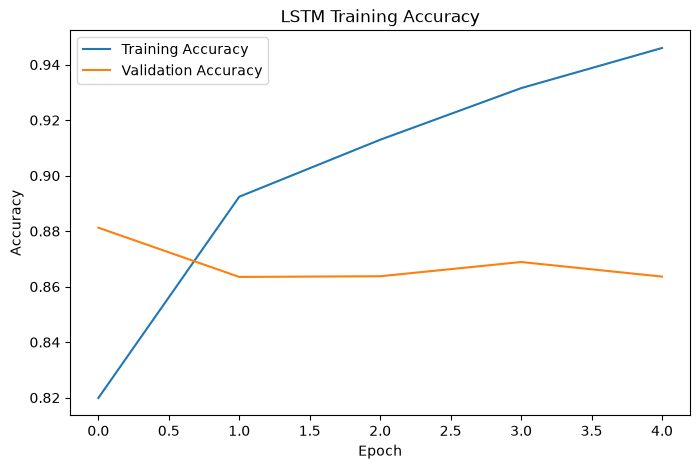

In [20]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training Accuracy")

plt.legend()

plt.show()

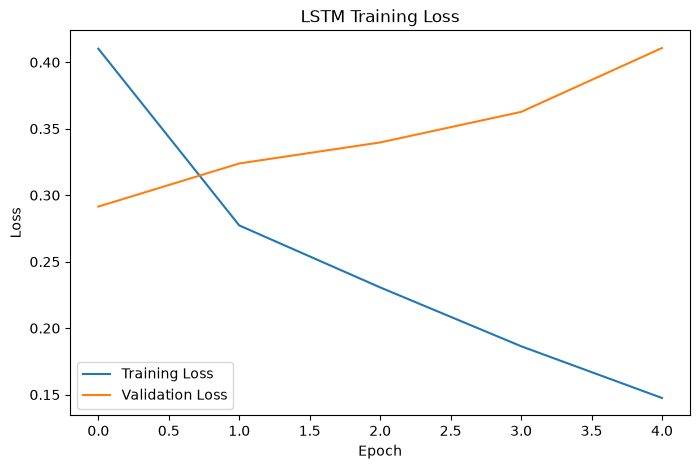

In [21]:
plt.figure(figsize=(8,5))


plt.plot(
    history.history["loss"],
    label="Training Loss"
)


plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "LSTM Training Loss"
)


plt.legend()

plt.show()

In [22]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)


print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.8687 - loss: 0.4146
Test Accuracy: 0.8687000274658203


In [23]:
predictions = model.predict(
    X_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step


In [24]:
predicted_classes = (
    predictions > 0.5
).astype("int32")

In [25]:
from sklearn.metrics import classification_report, confusion_matrix


print(
    classification_report(
        y_test,
        predicted_classes
    )
)

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      5000
           1       0.89      0.84      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



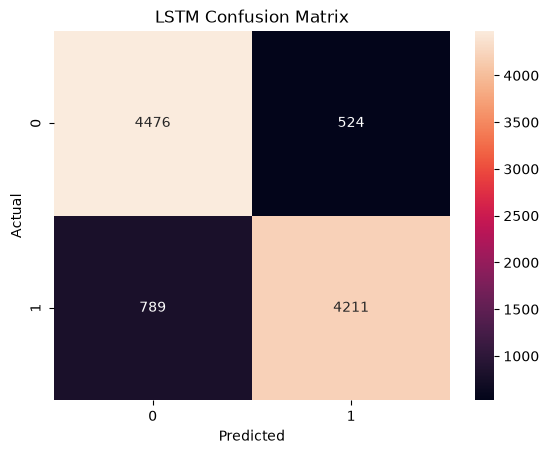

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(
    y_test,
    predicted_classes
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")

plt.show()

In [27]:
print(type(y_test))
print(type(predicted_classes))

<class 'pandas.Series'>
<class 'numpy.ndarray'>


In [28]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import load_model

In [29]:
df = pd.read_csv("../data/imdb_cleaned.csv")

df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [30]:
X = df["clean_review"]
y = df["sentiment"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
print(y_test.head())

33553    positive
9427     positive
199      negative
12447    positive
39489    negative
Name: sentiment, dtype: str


In [33]:
%whos

Variable                Type          Data/Info
-----------------------------------------------
Tokenizer               type          <class 'keras.src.legacy.<...>ocessing.text.Tokenizer'>
X                       Series        Shape: (50000,)
X_test                  Series        Shape: (10000,)
X_train                 Series        Shape: (40000,)
accuracy                float         0.8687000274658203
classification_report   function      <function classification_<...>rt at 0x000002AE9BF30400>
cm                      ndarray       2x2: 4 elems, type `int64`, 32 bytes
confusion_matrix        function      <function confusion_matrix at 0x000002AE9BF03060>
create_lstm_model       function      <function create_lstm_mod<...>el at 0x000002AEA7591F80>
df                      DataFrame     Shape: (50000, 3)
history                 History       <keras.src.callbacks.hist<...>ct at 0x000002AEA70AEF00>
load_model              function      <function load_model at 0x000002AEA4645A80>
loss    

In [34]:
model.save(
    "../models/lstm_model.h5"
)

print("LSTM model saved ✅")

LSTM model saved ✅


In [35]:
import pickle


with open(
    "../models/tokenizer.pkl",
    "wb"
) as file:

    pickle.dump(
        tokenizer,
        file
    )


print("Tokenizer saved ✅")

Tokenizer saved ✅


In [36]:
sample_review = [
    "This movie was amazing and I really enjoyed it"
]


sample_seq = tokenizer.texts_to_sequences(
    sample_review
)


sample_pad = pad_sequences(
    sample_seq,
    maxlen=200
)


prediction = model.predict(
    sample_pad
)


prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


array([[0.8789395]], dtype=float32)

In [ ]:
if prediction[0][0] > 0.5:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

Positive Review 😊


: 